# 📢 Project 4: Advertising Sales Prediction & ROI Analysis
### Multiple Linear Regression & Marketing Budget Optimization

In this project, we analyze how marketing expenditures across three distinct media channels—**TV**, **Radio**, and **Newspaper**—directly impact **Product Sales ($)**.

---

### 🎯 Business Objective
As a Data Scientist advising the Chief Marketing Officer (CMO):
1. **Model & Predict**: Build a Multiple Linear Regression model to forecast product sales given ad spend.
2. **Quantify Channel ROI**: Determine which advertising channel delivers the highest return per dollar spent.
3. **Budget Optimization**: Advise leadership on where to cut waste (e.g., ineffective media) and where to allocate future advertising capital.

---

### 🧭 Universal 6-Step Workflow
1. **Data Ingestion**: Download and verify raw dataset.
2. **EDA (D-M-D-T-O)**: Data Types, Missing Values, Duplicates, Target Distribution, Outliers & Correlation.
3. **Feature Selection & Preparation**: Drop index artifacts, construct feature matrix $X$ and target $y$.
4. **Train-Test Split**: 80% training, 20% testing with seed reproducibility.
5. **Model Training**: Fit Multiple Linear Regression (Ordinary Least Squares).
6. **Evaluation & Diagnostics**: Calculate MAE, RMSE, $R^2$, and inspect residual assumptions.
7. **Business Decisions & Simulation**: Interpret coefficients and run live what-if scenarios.

---
## 📥 Step 1: Library Imports & Data Ingestion
We import core scientific packages (`numpy`, `pandas`, `scipy`), plotting libraries (`matplotlib`, `seaborn`), and machine learning tools (`scikit-learn`, `joblib`).

In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Scikit-learn modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import kagglehub

print("✅ All core libraries successfully imported!")

✅ All core libraries successfully imported!


In [2]:
# Define dataset directory and ensure local availability
dest_dir = Path("data/advertising_sales")
dest_dir.mkdir(parents=True, exist_ok=True)

csv_files = list(dest_dir.glob("*.csv"))
if not csv_files:
    print("Downloading advertising sales dataset from Kaggle...")
    cache_path = kagglehub.dataset_download("yasserh/advertising-sales-dataset")
    shutil.copytree(cache_path, dest_dir, dirs_exist_ok=True)
    csv_files = list(dest_dir.glob("*.csv"))

csv_path = csv_files[0]
df = pd.read_csv(csv_path)

print(f"✅ Data loaded successfully from: {csv_path.name}")
print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Data loaded successfully from: Advertising Budget and Sales.csv
Dataset Shape: 200 rows, 5 columns


,Unnamed: 0,TV Ad Budget ($),Radio Ad Budget ($),Newspaper Ad Budget ($),Sales ($)
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


---
## 🔍 Step 2: Exploratory Data Analysis (The D-M-D-T-O Framework)

We systematically audit the dataset across the five essential pillars:
- **D** - Data Types
- **M** - Missing Values
- **D** - Duplicate Rows
- **T** - Target Variable Analysis
- **O** - Outliers & Bivariate Correlation

In [3]:
# [D] Data Types Audit
print("--- [D] Data Types Breakdown ---")
print(df.dtypes)
print("\nType Counts:")
print(df.dtypes.value_counts())

--- [D] Data Types Breakdown ---
Unnamed: 0                   int64
TV Ad Budget ($)           float64
Radio Ad Budget ($)        float64
Newspaper Ad Budget ($)    float64
Sales ($)                  float64
dtype: object

Type Counts:
float64    4
int64      1
Name: count, dtype: int64


In [4]:
# [M] Missing Values Audit
missing_counts = df.isnull().sum()
print("--- [M] Missing Values Count ---")
print(missing_counts)

assert missing_counts.sum() == 0, "Missing values detected!"
print("\n✅ Clean Data: 0 missing values across all columns.")

--- [M] Missing Values Count ---
Unnamed: 0                 0
TV Ad Budget ($)           0
Radio Ad Budget ($)        0
Newspaper Ad Budget ($)    0
Sales ($)                  0
dtype: int64

✅ Clean Data: 0 missing values across all columns.


In [5]:
# [D] Duplicate Rows Audit
dup_count = df.duplicated().sum()
print(f"--- [D] Duplicate Rows Count: {dup_count} ---")
if dup_count > 0:
    print(f"⚠️ {dup_count} duplicate rows found.")
else:
    print("✅ Clean Data: Zero duplicate rows detected.")

--- [D] Duplicate Rows Count: 0 ---
✅ Clean Data: Zero duplicate rows detected.


### [T] Target Variable Analysis (`Sales ($)`)
We inspect the 5-point summary, distribution shape, skewness, and normality of product sales.

--- Statistical Summary of Sales ($) ---
count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales ($), dtype: float64

Skewness: 0.4076 (Near 0 indicates well-balanced, symmetric distribution)


/tmp/ipykernel_2122548/3896624523.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(target, vert=False, patch_artist=True, boxprops=dict(facecolor="#2ca02c", alpha=0.6))


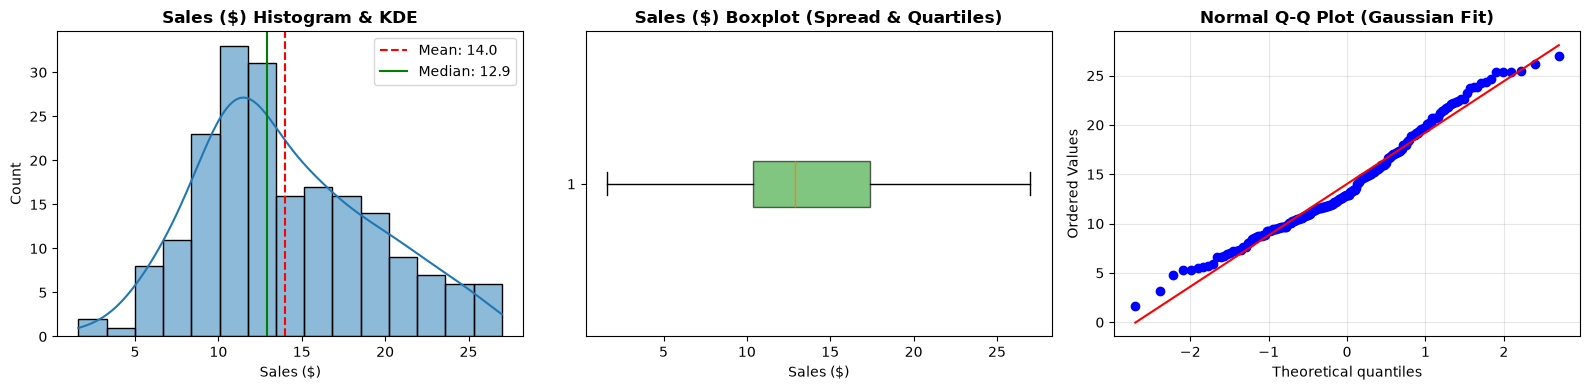

In [6]:
# [T] Target Distribution Statistics
target_col = "Sales ($)"
target = df[target_col]

print(f"--- Statistical Summary of {target_col} ---")
print(target.describe())
print(f"\nSkewness: {target.skew():.4f} (Near 0 indicates well-balanced, symmetric distribution)")

# 3-Panel Visual Diagnostics: Histogram, Boxplot, Q-Q Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Histogram + KDE
sns.histplot(target, kde=True, ax=axes[0], color="#1f77b4", bins=15)
axes[0].axvline(target.mean(), color="red", linestyle="--", label=f"Mean: {target.mean():.1f}")
axes[0].axvline(target.median(), color="green", linestyle="-", label=f"Median: {target.median():.1f}")
axes[0].set_title("Sales ($) Histogram & KDE", fontweight="bold")
axes[0].set_xlabel("Sales ($)")
axes[0].legend()

# 2. Boxplot
axes[1].boxplot(target, vert=False, patch_artist=True, boxprops=dict(facecolor="#2ca02c", alpha=0.6))
axes[1].set_title("Sales ($) Boxplot (Spread & Quartiles)", fontweight="bold")
axes[1].set_xlabel("Sales ($)")

# 3. Normal Q-Q Plot
stats.probplot(target, dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot (Gaussian Fit)", fontweight="bold")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### [O] Outliers & Bivariate Analysis
We analyze feature distributions for extreme values and explore how each media budget correlates with Sales.

/tmp/ipykernel_2122548/2811257271.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))
/tmp/ipykernel_2122548/2811257271.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))
/tmp/ipykernel_2122548/2811257271.py:7: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))


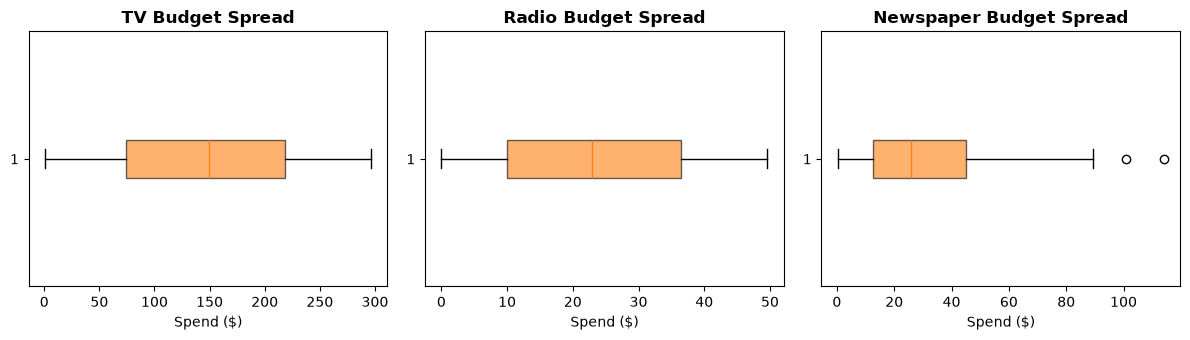

In [7]:
# 1. Boxplots for Ad Budgets to check for Outliers
features = ["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"]

plt.figure(figsize=(12, 3.5))
for idx, col in enumerate(features, 1):
    plt.subplot(1, 3, idx)
    plt.boxplot(df[col], vert=False, patch_artist=True, boxprops=dict(facecolor="#ff7f0e", alpha=0.6))
    plt.title(f"{col.split()[0]} Budget Spread", fontweight="bold")
    plt.xlabel("Spend ($)")
plt.tight_layout()
plt.show()

# Notice: Newspaper shows 2 slight data points above $100, while TV and Radio are uniformly distributed.

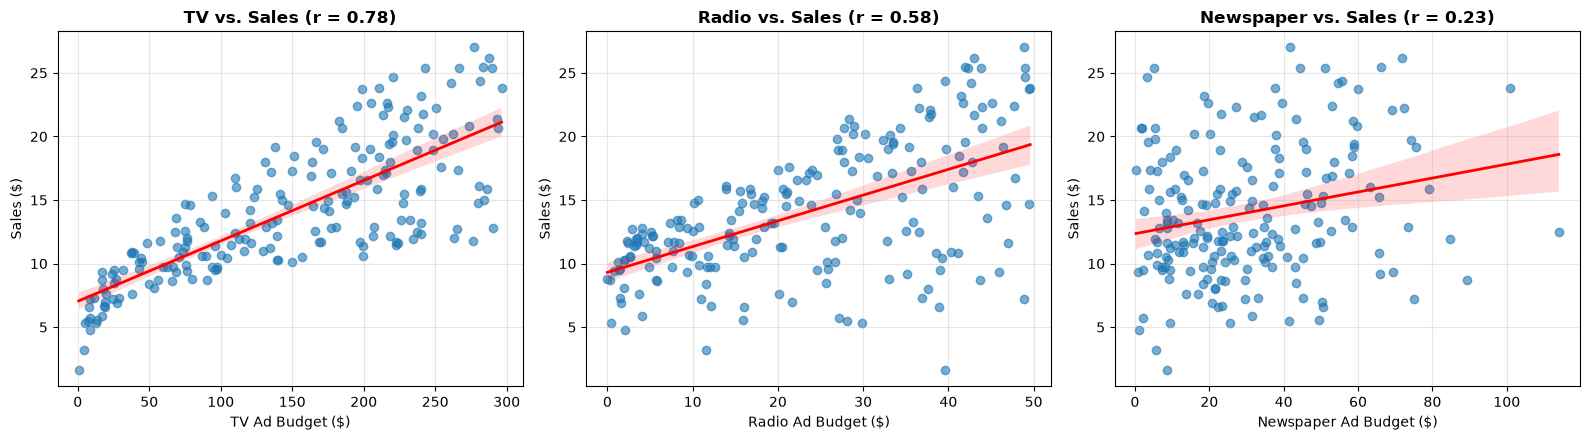

In [8]:
# 2. Bivariate Scatter Plots with Linear Trendlines
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for idx, col in enumerate(features):
    sns.regplot(data=df, x=col, y="Sales ($)", ax=axes[idx],
                scatter_kws={"alpha": 0.6, "color": "#1f77b4"},
                line_kws={"color": "red", "linewidth": 2})
    corr_val = df[col].corr(df["Sales ($)"])
    axes[idx].set_title(f"{col.split()[0]} vs. Sales (r = {corr_val:.2f})", fontweight="bold")
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

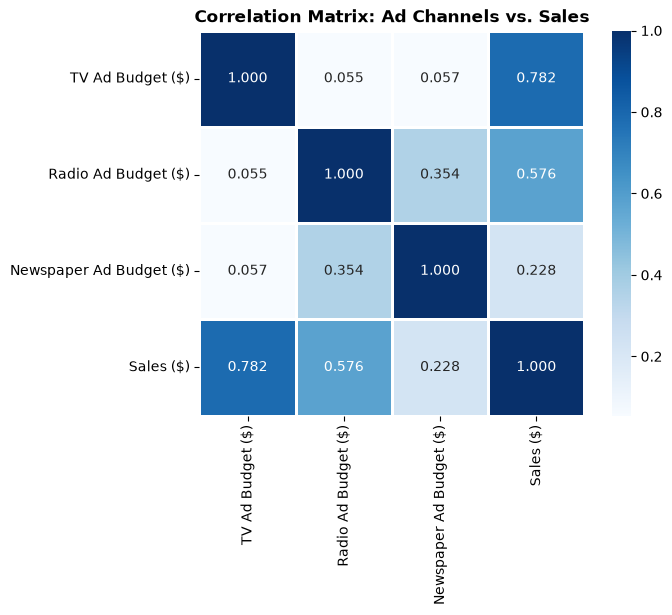

In [9]:
# 3. Correlation Matrix Heatmap
# Clean out artifact column 'Unnamed: 0' if present
if "Unnamed: 0" in df.columns:
    df_clean = df.drop(columns=["Unnamed: 0"])
else:
    df_clean = df.copy()

corr_matrix = df_clean.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="Blues", fmt=".3f", linewidths=1, square=True)
plt.title("Correlation Matrix: Ad Channels vs. Sales", fontsize=12, fontweight="bold")
plt.show()

---
## ⚙️ Step 3: Feature Selection & Train-Test Split

- **Feature Matrix ($X$)**: `TV Ad Budget ($)`, `Radio Ad Budget ($)`, `Newspaper Ad Budget ($)`
- **Target ($y$)**: `Sales ($)`
- **Data Splitting**: We allocate **80%** for model training and reserve **20%** strictly for unseen validation test evaluation.

In [10]:
# Define features and target
X = df_clean[["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"]]
y = df_clean["Sales ($)"]

# 80% Train, 20% Test Split with fixed random seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Total records:   {len(df_clean)}")
print(f"🏋️ Training set:   {X_train.shape[0]} samples ({X_train.shape[0]/len(df_clean)*100:.0f}%)")
print(f"🧪 Validation set: {X_test.shape[0]} samples ({X_test.shape[0]/len(df_clean)*100:.0f}%)")

✅ Total records:   200
🏋️ Training set:   160 samples (80%)
🧪 Validation set: 40 samples (20%)


---
## 🧠 Step 4: Model Training & Evaluation (Multiple Linear Regression)

We train Ordinary Least Squares (OLS) Linear Regression, along with Ridge (L2) and Lasso (L1) regularization benchmarks to verify coefficient stability.

In [11]:
# 1. Train Multiple Linear Regression
ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

# 2. Test Set Predictions
y_pred = ols_model.predict(X_test)

# 3. Calculate Performance Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 45)
print(" 📊 OLS REGRESSION TEST PERFORMANCE")
print("=" * 45)
print(f"R-squared (R²):                  {r2:.4f}  (~{r2*100:.1f}% variance explained)")
print(f"Mean Absolute Error (MAE):       {mae:.4f} units")
print(f"Root Mean Squared Error (RMSE):  {rmse:.4f} units")
print("=" * 45)

 📊 OLS REGRESSION TEST PERFORMANCE
R-squared (R²):                  0.8994  (~89.9% variance explained)
Mean Absolute Error (MAE):       1.4608 units
Root Mean Squared Error (RMSE):  1.7816 units


In [12]:
# Regularization Benchmark: Compare OLS vs Ridge vs Lasso
ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

model_comparison = pd.DataFrame({
    "Model": ["Linear Regression (OLS)", "Ridge Regression (L2)", "Lasso Regression (L1)"],
    "R² Score": [r2_score(y_test, ols_model.predict(X_test)),
                 r2_score(y_test, ridge.predict(X_test)),
                 r2_score(y_test, lasso.predict(X_test))],
    "MAE": [mean_absolute_error(y_test, ols_model.predict(X_test)),
            mean_absolute_error(y_test, ridge.predict(X_test)),
            mean_absolute_error(y_test, lasso.predict(X_test))],
    "RMSE": [np.sqrt(mean_squared_error(y_test, ols_model.predict(X_test))),
             np.sqrt(mean_squared_error(y_test, ridge.predict(X_test))),
             np.sqrt(mean_squared_error(y_test, lasso.predict(X_test)))]
})

model_comparison.round(4)

,Model,R² Score,MAE,RMSE
0,Linear Regression (OLS),0.8994,1.4608,1.7816
1,Ridge Regression (L2),0.8994,1.4608,1.7816
2,Lasso Regression (L1),0.9004,1.4522,1.7730


---
## 📈 Step 5: Diagnostic Visualizations (Actual vs. Predicted & Residuals)

To validate the Gauss-Markov assumptions of linear regression:
1. **Actual vs. Predicted Plot**: Predictions should closely follow the 45-degree identity line.
2. **Residual Plot**: Residuals ($y - \hat{y}$) should be randomly scattered around zero with constant variance (Homoscedasticity).

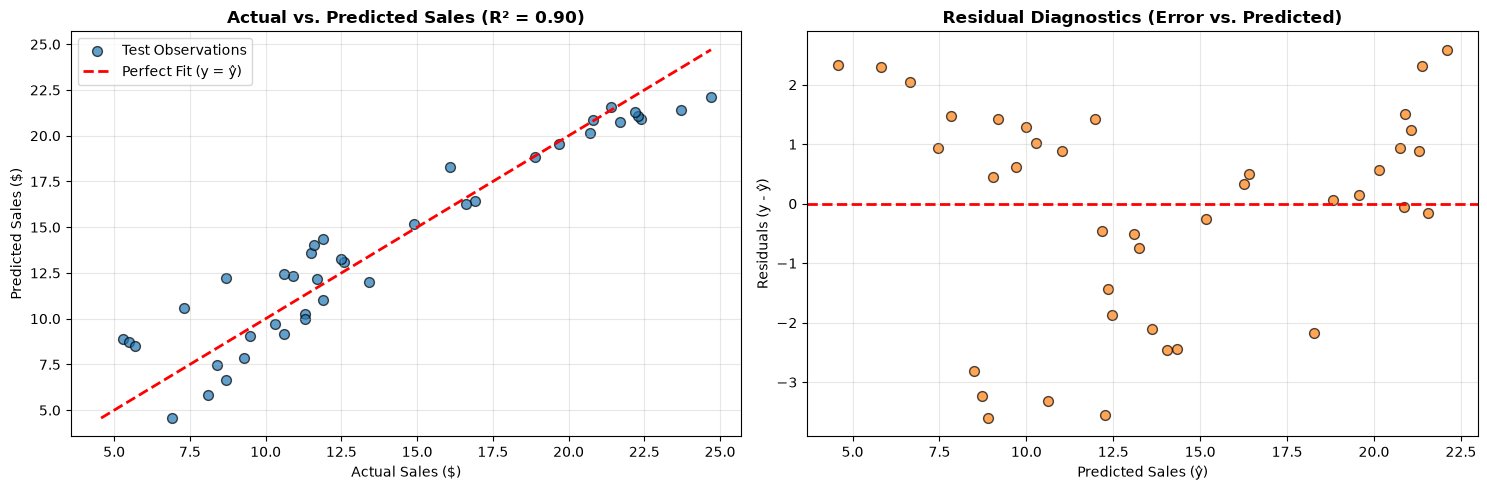

In [13]:
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred, color="#1f77b4", alpha=0.7, edgecolors="k", s=50, label="Test Observations")
min_pt = min(y_test.min(), y_pred.min())
max_pt = max(y_test.max(), y_pred.max())
axes[0].plot([min_pt, max_pt], [min_pt, max_pt], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = ŷ)")
axes[0].set_title(f"Actual vs. Predicted Sales (R² = {r2:.2f})", fontweight="bold")
axes[0].set_xlabel("Actual Sales ($)")
axes[0].set_ylabel("Predicted Sales ($)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Predicted (Homoscedasticity Check)
axes[1].scatter(y_pred, residuals, color="#ff7f0e", alpha=0.7, edgecolors="k", s=50)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Diagnostics (Error vs. Predicted)", fontweight="bold")
axes[1].set_xlabel("Predicted Sales (ŷ)")
axes[1].set_ylabel("Residuals (y - ŷ)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 💡 Step 6: Model Coefficients & The Marketing ROI Decision Framework

The fitted regression equation is:
$$\text{Sales} = \beta_0 + (\beta_1 \times \text{TV}) + (\beta_2 \times \text{Radio}) + (\beta_3 \times \text{Newspaper})$$

In [14]:
# Extract parameters
intercept = ols_model.intercept_
coefs = ols_model.coef_

coef_summary = pd.DataFrame({
    "Ad Medium": X.columns,
    "Coefficient (Beta)": coefs,
    "Sales Gain per $100 Spend": coefs * 100
}).sort_values(by="Coefficient (Beta)", ascending=False).reset_index(drop=True)

print(f"Base Baseline Sales (Intercept β₀): {intercept:.4f} units")
print("\n--- Marketing Channel Effectiveness ---")
print(coef_summary.to_string(index=False))

Base Baseline Sales (Intercept β₀): 2.9791 units

--- Marketing Channel Effectiveness ---
              Ad Medium  Coefficient (Beta)  Sales Gain per $100 Spend
    Radio Ad Budget ($)            0.189195                  18.919505
       TV Ad Budget ($)            0.044730                   4.472952
Newspaper Ad Budget ($)            0.002761                   0.276111


### 💼 Executive Insights & Recommendations for the CMO:
1. **Radio is the Highest ROI Channel**:
   - $\beta_{Radio} = 0.1892$: Each **$100 spent on Radio generates ~18.9 units of sales**.
   - Radio is more than **4x more cost-efficient** than TV per dollar allocated.
2. **TV is the Core Volume Driver**:
   - $\beta_{TV} = 0.0447$: Each **$100 spent on TV yields ~4.5 units of sales**.
   - While the per-dollar ROI is lower than Radio, TV supports massive scale without rapid saturation.
3. **Newspaper is Dead Weight**:
   - $\beta_{Newspaper} = 0.0028$: Each **$100 spent on Newspaper yields negligible return (<0.3 units)**.
   - **Action Item**: Eliminate or drastically cut newspaper ad spend and reallocate those funds directly to Radio and TV.

---
## 🎯 Step 7: Live Budget Allocation Simulation (What-If Analysis)

We simulate two competing budget proposals for next quarter's advertising strategy:
- **Option A (Traditional/Status Quo)**: TV: $150k, Radio: $20k, Newspaper: $30k (Total: $200k)
- **Option B (Data-Driven Reallocation)**: TV: $130k, Radio: $70k, Newspaper: $0k (Total: $200k)

In [15]:
# Define simulation scenarios
scenarios_df = pd.DataFrame([
    {"Scenario": "Option A: Status Quo", "TV Ad Budget ($)": 150.0, "Radio Ad Budget ($)": 20.0, "Newspaper Ad Budget ($)": 30.0},
    {"Scenario": "Option B: Data-Driven", "TV Ad Budget ($)": 130.0, "Radio Ad Budget ($)": 70.0, "Newspaper Ad Budget ($)": 0.0}
])

pred_features = scenarios_df[["TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)"]]
scenarios_df["Predicted Sales ($)"] = ols_model.predict(pred_features)

print("--- What-If Budget Simulation Comparison ($200 Total Budget) ---")
print(scenarios_df[["Scenario", "TV Ad Budget ($)", "Radio Ad Budget ($)", "Newspaper Ad Budget ($)", "Predicted Sales ($)"]].to_string(index=False))

sales_diff = scenarios_df.loc[1, "Predicted Sales ($)"] - scenarios_df.loc[0, "Predicted Sales ($)"]
print(f"\n🚀 Data-Driven Reallocation yields an extra +{sales_diff:.2f} units of sales with ZERO extra budget!")

--- What-If Budget Simulation Comparison ($200 Total Budget) ---
             Scenario  TV Ad Budget ($)  Radio Ad Budget ($)  Newspaper Ad Budget ($)  Predicted Sales ($)
 Option A: Status Quo             150.0                 20.0                     30.0            13.555229
Option B: Data-Driven             130.0                 70.0                      0.0            22.037558

🚀 Data-Driven Reallocation yields an extra +8.48 units of sales with ZERO extra budget!


---
## 💾 Step 8: Model Serialization & Production Deployment

We serialize the trained Linear Regression model using `joblib` for API/application deployment.

In [16]:
# Save trained model to disk
model_dir = Path("data/advertising_sales")
model_dir.mkdir(parents=True, exist_ok=True)
model_file = model_dir / "advertising_sales_model.pkl"

joblib.dump(ols_model, model_file)
print(f"✅ Model successfully saved to: {model_file}")

# Smoke test: Reload model and verify prediction
loaded_model = joblib.load(model_file)
test_pred = loaded_model.predict([[200.0, 40.0, 0.0]])
print(f"🧪 Smoke Test - Prediction for TV=$200, Radio=$40, News=$0: {test_pred[0]:.2f} sales")

✅ Model successfully saved to: data/advertising_sales/advertising_sales_model.pkl
🧪 Smoke Test - Prediction for TV=$200, Radio=$40, News=$0: 19.49 sales


/home/python/03_Custom_addons/ML/.venv/lib/python3.11/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
